# Comparaison de Modèles sur M-values (sans Data Leakage, 5-Fold CV)

## Conversion B-values → M-values
$$M = \log_2\left(\frac{\beta}{1 - \beta}\right)$$

Les M-values sont plus adaptées aux modèles linéaires (distribution plus proche de la normale),  
tandis que les B-values (β ∈ [0,1]) sont plus interprétables biologiquement.

## Protocole rigoureux
1. **Conversion** B-values → M-values (sur données brutes, avant tout traitement)
2. Chargement de **tous les CpG** (M-values, avec NaN)
3. **5-Fold CV** pour l'évaluation
4. **À l'intérieur de chaque fold** (train only) :
   - Sélection top-500 par corrélation avec l'âge (train only)
   - **Imputation MICE** : fit sur train, transform sur test (aucun leakage)
   - **Normalisation StandardScaler** : fit sur train, transform sur test (aucun leakage)
   - Paramètres MICE optimisés : BayesianRidge, n_nearest_features=100, max_iter=10
   - Entraînement des modèles
5. **Intervalles de confiance** à 95%

## Modèles comparés
1. ElasticNetCV (top 500 CpG)  
2. ResidualLearning (top 500 CpG)  
3. ElasticNetCV (top 500 CpG + sexe)  
4. Sous-modèles par catégorie d'âge  
5. ElasticNetCV (RFECV intra-fold)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.linear_model import ElasticNet, ElasticNetCV, LinearRegression, BayesianRidge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('Data')
TOP_K = 500
N_FOLDS = 5
CHUNK_SIZE = 5000

# Meilleurs paramètres MICE (issus de l'optimisation)
MICE_PARAMS = {
    'estimator': BayesianRidge(),
    'n_nearest_features': 100,
    'max_iter': 10,
    'random_state': RANDOM_STATE,
}

# Clip pour éviter log2(0) et division par 0
BETA_EPS = 1e-6

def beta_to_m(beta):
    """Convertit B-values en M-values : M = log2(beta / (1 - beta)).
    Clip beta dans [eps, 1-eps] pour éviter -inf/+inf. Préserve les NaN."""
    b = np.clip(beta, BETA_EPS, 1.0 - BETA_EPS)
    # Restaurer les NaN (clip transforme NaN en valeur clippée)
    b = np.where(np.isnan(beta), np.nan, b)
    return np.log2(b / (1.0 - b))

print('Imports OK')

Imports OK


## Helpers et ResidualLearningPipeline

In [2]:
def select_top_k(X_train, y_train, k):
    """Sélection top-k features par corrélation absolue (NaN-safe, train only)."""
    y_c = y_train - y_train.mean()
    y_den = np.sqrt(np.sum(y_c ** 2))
    # Remplacer NaN par la moyenne de chaque colonne pour le calcul de corrélation
    col_means = np.nanmean(X_train, axis=0, keepdims=True)
    X_filled = np.where(np.isnan(X_train), col_means, X_train)
    x_c = X_filled - X_filled.mean(axis=0, keepdims=True)
    num = x_c.T @ y_c
    den = np.sqrt(np.sum(x_c ** 2, axis=0)) * y_den
    corrs = np.abs(np.divide(num, den, out=np.zeros_like(num), where=den != 0))
    return np.argsort(corrs)[::-1][:k]


class ResidualLearningPipeline:
    """ElasticNetCV + XGBoost résidus + Bias Correction."""
    def __init__(self, enet_cv=3, xgb_n_estimators=300, xgb_early_stopping_rounds=30):
        self.enet_cv = enet_cv
        self.xgb_params = dict(
            n_estimators=xgb_n_estimators, max_depth=3, learning_rate=0.03,
            subsample=0.7, colsample_bytree=0.5, reg_alpha=10.0, reg_lambda=50.0,
            min_child_weight=10, early_stopping_rounds=xgb_early_stopping_rounds,
            objective='reg:squarederror', eval_metric='mae',
            n_jobs=-1, random_state=RANDOM_STATE,
        )
        self.enet_ = None
        self.xgb_ = None
        self.bias_ = None

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self.enet_ = ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], n_alphas=50,
            cv=self.enet_cv, max_iter=50000, random_state=RANDOM_STATE, n_jobs=-1,
        )
        self.enet_.fit(X_train, y_train)
        P_lin = self.enet_.predict(X_train)
        residuals = y_train - P_lin

        self.xgb_ = XGBRegressor(**self.xgb_params)
        if X_val is not None and y_val is not None:
            P_val = self.enet_.predict(X_val)
            self.xgb_.fit(X_train, residuals,
                          eval_set=[(X_val, y_val - P_val)], verbose=False)
        else:
            self.xgb_.fit(X_train, residuals,
                          eval_set=[(X_train, residuals)], verbose=False)

        R_hat = self.xgb_.predict(X_train)
        self.bias_ = LinearRegression()
        self.bias_.fit(np.column_stack([P_lin, R_hat]), y_train)
        return self

    def predict(self, X):
        P_lin = self.enet_.predict(X)
        R_hat = self.xgb_.predict(X)
        return self.bias_.predict(np.column_stack([P_lin, R_hat]))

## Chargement des Données Brutes + Conversion en M-values

1. Chargement de **tous les CpG** en B-values brutes (avec NaN) depuis `c_sample.csv`
2. **Conversion B → M** : $M = \log_2(\beta / (1 - \beta))$, clip $\beta \in [10^{-6}, 1-10^{-6}]$

La sélection de features, l'imputation MICE et la normalisation seront faites **intra-fold**.

In [3]:
# --- Annotations ---
ind = pd.read_csv(DATA_DIR / 'annot_projet.csv')
ind = ind.dropna(subset=['age', 'Sample_description']).copy()
ind['Sample_description'] = ind['Sample_description'].astype(str)
ind = ind.set_index('Sample_description')

# --- Données BRUTES (B-values avec NaN) ---
data_path = DATA_DIR / 'c_sample.csv'
sample_header = pd.read_csv(data_path, nrows=0)
all_sample_ids = list(sample_header.columns)
common_ids = [s for s in all_sample_ids if s in ind.index]
y = ind.loc[common_ids, 'age'].values.astype(np.float32)
print(f'Échantillons : {len(common_ids)}, âge moyen : {y.mean():.1f} ± {y.std():.1f}')

# --- Sexe ---
sex = ind.loc[common_ids, 'female'].apply(
    lambda x: 1.0 if str(x).lower() == 'true' else (0.0 if str(x).lower() == 'false' else np.nan)
).values.astype(np.float32)
sex = np.where(np.isnan(sex), np.nanmean(sex), sex)

# --- Charger TOUS les CpG et convertir B-values -> M-values ---
print(f'\nChargement de tous les CpG + conversion B -> M-values...')
t0 = time()
rows = []
for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    beta = chunk.to_numpy(dtype=np.float32)
    rows.append(beta_to_m(beta))

X_all = np.vstack(rows).T.astype(np.float32)  # (n_samples, n_cpg)
nan_pct = np.isnan(X_all).mean() * 100
print(f'  Chargé en {time()-t0:.1f}s, shape={X_all.shape}, NaN={nan_pct:.2f}%')
print(f'  M-values range : [{np.nanmin(X_all):.2f}, {np.nanmax(X_all):.2f}]')
print(f'  M-values mean  : {np.nanmean(X_all):.3f}, std : {np.nanstd(X_all):.3f}')

Échantillons : 400, âge moyen : 53.0 ± 21.2

Chargement de tous les CpG + conversion B -> M-values...
  Chargé en 31.6s, shape=(400, 894006), NaN=2.67%
  M-values range : [-9.64, 8.96]
  M-values mean  : 0.975, std : 3.313


## 5-Fold Cross-Validation sur M-values (sans leakage)

Pour chaque fold :
1. Sélection top-500 par corrélation sur **train uniquement** (tous CpG -> 500, NaN-safe)
2. **Imputation MICE** : fit sur train, transform sur test (BayesianRidge, n_nearest_features=100)
3. **StandardScaler** : fit sur train imputé, transform sur test imputé
4. RFECV sur **train normalisé uniquement** (500 -> optimal)
5. Entraînement des 5 modèles

In [4]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

n_cpg_total = X_all.shape[1]

model_names = [
    '1. ElasticNetCV (corr)',
    '2. Residual Learning',
    '3. ElasticNetCV (+ sexe)',
    '4. Sous-modèles âge',
    '5. ElasticNetCV (RFECV)',
]
scores = {name: {'mae': [], 'r2': [], 'n_feat': []} for name in model_names}
AGE_BINS = [(0, 40, 'jeune'), (40, 65, 'moyen'), (65, 120, 'senior')]

print('=' * 70)
print(f'  5-Fold CV (M-values normalisées) | {n_cpg_total} CpG -> Sélection: {TOP_K} (corr intra-fold)')
print(f'  MICE: BayesianRidge, n_nearest_features=100, max_iter=10')
print(f'  Normalisation: StandardScaler (fit train, transform test)')
print('=' * 70)

for fold_i, (train_idx, test_idx) in enumerate(kf.split(y)):
    print('\n' + '=' * 55)
    print(f'  Fold {fold_i + 1}/{N_FOLDS}  (train={len(train_idx)}, test={len(test_idx)})')
    print('=' * 55)

    y_train, y_test = y[train_idx], y[test_idx]
    X_train_all, X_test_all = X_all[train_idx], X_all[test_idx]
    sex_train, sex_test = sex[train_idx], sex[test_idx]

    # === Sélection supervisée INTRA-FOLD (train only, NaN-safe) ===
    top_idx = select_top_k(X_train_all, y_train, TOP_K)
    X_tr_raw = X_train_all[:, top_idx]
    X_te_raw = X_test_all[:, top_idx]

    # === IMPUTATION MICE : fit sur train, transform sur test ===
    t0 = time()
    mice = IterativeImputer(**MICE_PARAMS)
    X_tr_imp = mice.fit_transform(X_tr_raw)
    X_te_imp = mice.transform(X_te_raw)
    print(f'  MICE imputation: {time()-t0:.1f}s (train NaN: {np.isnan(X_tr_raw).sum()}, test NaN: {np.isnan(X_te_raw).sum()})')

    # === NORMALISATION : fit sur train, transform sur test ===
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_imp)
    X_te = scaler.transform(X_te_imp)
    print(f'  StandardScaler: fit sur train, transform sur test')

    # --- 1. ElasticNetCV (top-k corrélation) ---
    enet = ElasticNetCV(cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    enet.fit(X_tr, y_train)
    y_pred_1 = enet.predict(X_te)
    scores['1. ElasticNetCV (corr)']['mae'].append(mean_absolute_error(y_test, y_pred_1))
    scores['1. ElasticNetCV (corr)']['r2'].append(r2_score(y_test, y_pred_1))
    scores['1. ElasticNetCV (corr)']['n_feat'].append(TOP_K)
    print(f"  1. ElasticNetCV (corr)    MAE: {scores['1. ElasticNetCV (corr)']['mae'][-1]:.3f}")

    # --- 2. Residual Learning (early stopping sur train uniquement) ---
    rl = ResidualLearningPipeline(enet_cv=3)
    rl.fit(X_tr, y_train)
    y_pred_2 = rl.predict(X_te)
    scores['2. Residual Learning']['mae'].append(mean_absolute_error(y_test, y_pred_2))
    scores['2. Residual Learning']['r2'].append(r2_score(y_test, y_pred_2))
    scores['2. Residual Learning']['n_feat'].append(TOP_K)
    print(f"  2. Residual Learning      MAE: {scores['2. Residual Learning']['mae'][-1]:.3f}")

    # --- 3. ElasticNetCV (CpG + sexe) ---
    X_tr_sex = np.column_stack([X_tr, sex_train])
    X_te_sex = np.column_stack([X_te, sex_test])
    enet_sex = ElasticNetCV(cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    enet_sex.fit(X_tr_sex, y_train)
    y_pred_3 = enet_sex.predict(X_te_sex)
    scores['3. ElasticNetCV (+ sexe)']['mae'].append(mean_absolute_error(y_test, y_pred_3))
    scores['3. ElasticNetCV (+ sexe)']['r2'].append(r2_score(y_test, y_pred_3))
    scores['3. ElasticNetCV (+ sexe)']['n_feat'].append(TOP_K + 1)
    print(f"  3. ElasticNetCV (+ sexe)  MAE: {scores['3. ElasticNetCV (+ sexe)']['mae'][-1]:.3f}")

    # --- 4. Sous-modèles par catégorie d'âge ---
    age_cat_train = np.digitize(y_train, bins=[40, 65])
    clf = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=RANDOM_STATE)
    clf.fit(X_tr, age_cat_train)
    age_cat_pred = clf.predict(X_te)

    sub_models = {}
    for cat_id, (lo, hi, label) in enumerate(AGE_BINS):
        mask = age_cat_train == cat_id
        n_cat = mask.sum()
        if n_cat < 10:
            sub_models[cat_id] = enet
        else:
            sub = ElasticNetCV(cv=min(5, n_cat // 2), random_state=RANDOM_STATE, n_jobs=-1)
            sub.fit(X_tr[mask], y_train[mask])
            sub_models[cat_id] = sub

    y_pred_4 = np.zeros(len(y_test))
    for cat_id in range(3):
        m = age_cat_pred == cat_id
        if m.sum() > 0:
            y_pred_4[m] = sub_models[cat_id].predict(X_te[m])
    scores['4. Sous-modèles âge']['mae'].append(mean_absolute_error(y_test, y_pred_4))
    scores['4. Sous-modèles âge']['r2'].append(r2_score(y_test, y_pred_4))
    scores['4. Sous-modèles âge']['n_feat'].append(TOP_K)
    print(f"  4. Sous-modèles âge       MAE: {scores['4. Sous-modèles âge']['mae'][-1]:.3f}")

    # --- 5. ElasticNetCV (RFECV intra-fold sur les 500 features normalisées) ---
    t0 = time()
    rfecv = RFECV(
        estimator=ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE),
        step=50, min_features_to_select=50, cv=3,
        scoring='neg_mean_absolute_error', n_jobs=-1,
    )
    rfecv.fit(X_tr, y_train)
    rfecv_mask = rfecv.support_
    n_rfecv = rfecv_mask.sum()

    enet_rfecv = ElasticNetCV(cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    enet_rfecv.fit(X_tr[:, rfecv_mask], y_train)
    y_pred_5 = enet_rfecv.predict(X_te[:, rfecv_mask])
    scores['5. ElasticNetCV (RFECV)']['mae'].append(mean_absolute_error(y_test, y_pred_5))
    scores['5. ElasticNetCV (RFECV)']['r2'].append(r2_score(y_test, y_pred_5))
    scores['5. ElasticNetCV (RFECV)']['n_feat'].append(n_rfecv)
    print(f"  5. ElasticNetCV (RFECV)   MAE: {scores['5. ElasticNetCV (RFECV)']['mae'][-1]:.3f}  (n={n_rfecv}, {time()-t0:.0f}s)")

print('\n' + '=' * 70)
print('5-Fold CV (M-values normalisées) terminée.')

  5-Fold CV (M-values normalisées) | 894006 CpG -> Sélection: 500 (corr intra-fold)
  MICE: BayesianRidge, n_nearest_features=100, max_iter=10
  Normalisation: StandardScaler (fit train, transform test)

  Fold 1/5  (train=320, test=80)
  MICE imputation: 230.6s (train NaN: 21589, test NaN: 5062)
  StandardScaler: fit sur train, transform sur test
  1. ElasticNetCV (corr)    MAE: 3.943
  2. Residual Learning      MAE: 3.366
  3. ElasticNetCV (+ sexe)  MAE: 3.943
  4. Sous-modèles âge       MAE: 3.456
  5. ElasticNetCV (RFECV)   MAE: 3.996  (n=388, 3s)

  Fold 2/5  (train=320, test=80)
  MICE imputation: 111.3s (train NaN: 41888, test NaN: 10499)
  StandardScaler: fit sur train, transform sur test
  1. ElasticNetCV (corr)    MAE: 3.348
  2. Residual Learning      MAE: 3.389
  3. ElasticNetCV (+ sexe)  MAE: 3.348
  4. Sous-modèles âge       MAE: 3.775
  5. ElasticNetCV (RFECV)   MAE: 4.269  (n=222, 2s)

  Fold 3/5  (train=320, test=80)
  MICE imputation: 455.3s (train NaN: 13581, test Na

## Résultats avec Intervalles de Confiance 95%

In [5]:
t_crit = stats.t.ppf(0.975, df=N_FOLDS - 1)

print('\n' + '=' * 85)
print(f'  COMPARAISON FINALE M-VALUES ({N_FOLDS}-fold CV, IC 95%)')
print(f'  {n_cpg_total} CpG -> Sélection: {TOP_K} (corr intra-fold)')
print(f'  MICE: BayesianRidge, n_nearest_features=100 (fit train, transform test)')
print('=' * 85)
print(f"{'Modèle':<28s} | {'n_feat':>6s} | {'MAE (95% CI)':<22s} | {'R² (95% CI)':<22s}")
print('-' * 28 + '-+-' + '-' * 6 + '-+-' + '-' * 22 + '-+-' + '-' * 22)

summary_rows = []
for name, s in scores.items():
    mae_arr = np.array(s['mae'])
    r2_arr = np.array(s['r2'])
    mae_ci = t_crit * mae_arr.std(ddof=1) / np.sqrt(N_FOLDS)
    r2_ci = t_crit * r2_arr.std(ddof=1) / np.sqrt(N_FOLDS)
    nf = int(np.mean(s['n_feat']))
    print(f'{name:<28s} | {nf:>6d} | {mae_arr.mean():.3f} ± {mae_ci:.3f}         | {r2_arr.mean():.3f} ± {r2_ci:.3f}')
    summary_rows.append({
        'Modèle': name, 'n_feat': nf,
        'MAE_mean': mae_arr.mean(), 'MAE_ci95': mae_ci,
        'R2_mean': r2_arr.mean(), 'R2_ci95': r2_ci,
    })

df_summary = pd.DataFrame(summary_rows).sort_values('MAE_mean')
best = df_summary.iloc[0]
print(f"\n  -> Meilleur : {best['Modèle']} (MAE = {best['MAE_mean']:.3f} ± {best['MAE_ci95']:.3f})")

df_summary.to_csv('results/model_comparison_m_values_results.csv', index=False)
print('  Résultats sauvegardés : results/model_comparison_m_values_results.csv')


  COMPARAISON FINALE M-VALUES (5-fold CV, IC 95%)
  894006 CpG -> Sélection: 500 (corr intra-fold)
  MICE: BayesianRidge, n_nearest_features=100 (fit train, transform test)
Modèle                       | n_feat | MAE (95% CI)           | R² (95% CI)           
-----------------------------+--------+------------------------+-----------------------
1. ElasticNetCV (corr)       |    500 | 4.012 ± 0.498         | 0.902 ± 0.062
2. Residual Learning         |    500 | 3.752 ± 0.633         | 0.911 ± 0.057
3. ElasticNetCV (+ sexe)     |    501 | 4.011 ± 0.497         | 0.901 ± 0.063
4. Sous-modèles âge          |    500 | 4.110 ± 0.617         | 0.889 ± 0.070
5. ElasticNetCV (RFECV)      |    250 | 4.313 ± 0.351         | 0.885 ± 0.051

  -> Meilleur : 2. Residual Learning (MAE = 3.752 ± 0.633)
  Résultats sauvegardés : results/model_comparison_m_values_results.csv


## Visualisations

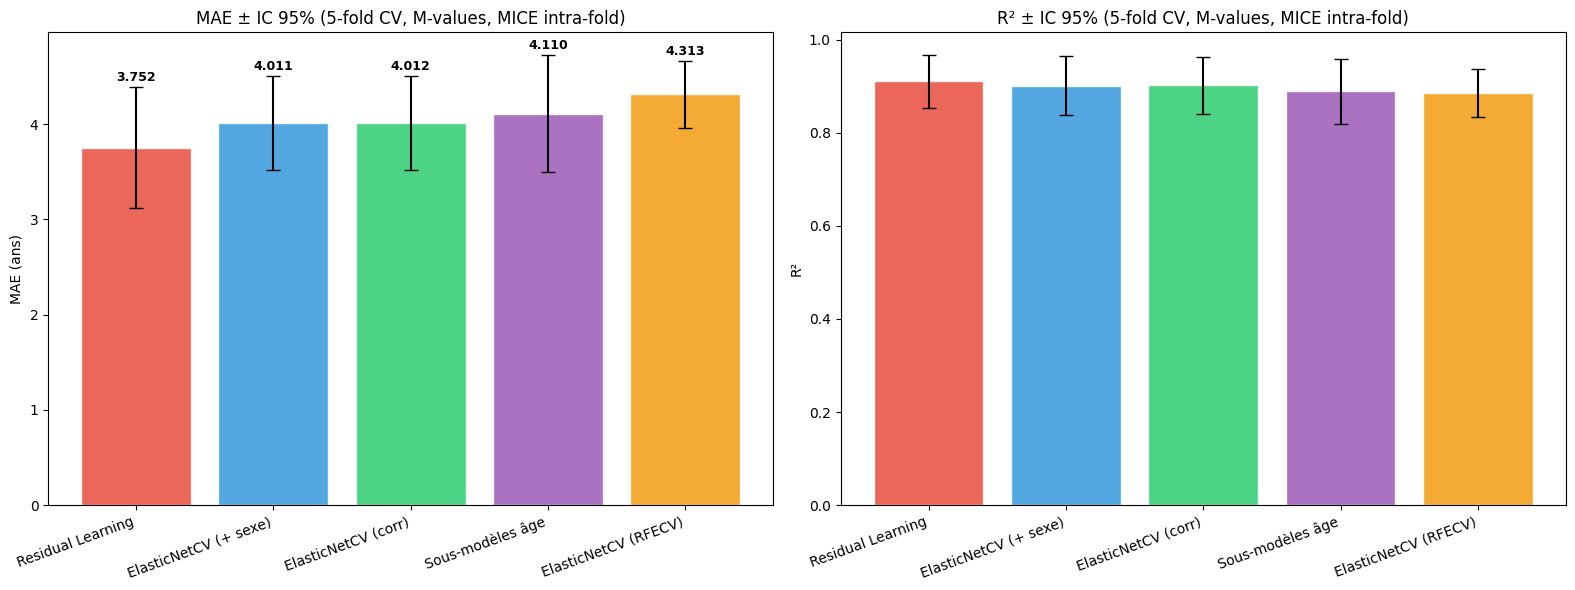

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models = df_summary['Mod\u00e8le'].tolist()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

ax = axes[0]
mae_m = df_summary['MAE_mean'].values
mae_c = df_summary['MAE_ci95'].values
bars = ax.bar(range(len(models)), mae_m, yerr=mae_c, capsize=5,
              color=colors[:len(models)], alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split('. ')[1] for m in models], rotation=20, ha='right')
ax.set_ylabel('MAE (ans)')
ax.set_title(f'MAE \u00b1 IC 95% ({N_FOLDS}-fold CV, M-values, MICE intra-fold)')
for bar, m, c in zip(bars, mae_m, mae_c):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + c + 0.03,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax = axes[1]
r2_m = df_summary['R2_mean'].values
r2_c = df_summary['R2_ci95'].values
bars = ax.bar(range(len(models)), r2_m, yerr=r2_c, capsize=5,
              color=colors[:len(models)], alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split('. ')[1] for m in models], rotation=20, ha='right')
ax.set_ylabel('R\u00b2')
ax.set_title(f'R\u00b2 \u00b1 IC 95% ({N_FOLDS}-fold CV, M-values, MICE intra-fold)')

plt.tight_layout()
plt.savefig('results/model_comparison_m_values_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Résumé

In [7]:
print('=' * 75)
print('  RÉSUMÉ M-VALUES (sans data leakage)')
print('=' * 75)
print(f'  Données      : B-values brutes (c_sample.csv) converties en M-values, {n_cpg_total} CpG')
print(f'  Conversion   : M = log2(beta / (1 - beta)), clip [{BETA_EPS}, {1-BETA_EPS}]')
print(f'  Sélection    : {TOP_K} CpG par corrélation (intra-fold, train only)')
print(f'  Imputation   : MICE (BayesianRidge, n_nearest=100, fit train / transform test)')
print(f'  Normalisation: StandardScaler (fit train / transform test)')
print(f'  RFECV        : intra-fold sur {TOP_K} features normalisées (train only)')
print(f'  CV           : {N_FOLDS}-fold')
print(f'  IC 95%       : t-Student (df={N_FOLDS-1})')
print()
print(df_summary.to_string(index=False))
print(f"\n  Meilleur : {best['Modèle']} (MAE = {best['MAE_mean']:.3f} ± {best['MAE_ci95']:.3f})")
print('\n' + '=' * 75)

  RÉSUMÉ M-VALUES (sans data leakage)
  Données      : B-values brutes (c_sample.csv) converties en M-values, 894006 CpG
  Conversion   : M = log2(beta / (1 - beta)), clip [1e-06, 0.999999]
  Sélection    : 500 CpG par corrélation (intra-fold, train only)
  Imputation   : MICE (BayesianRidge, n_nearest=100, fit train / transform test)
  Normalisation: StandardScaler (fit train / transform test)
  RFECV        : intra-fold sur 500 features normalisées (train only)
  CV           : 5-fold
  IC 95%       : t-Student (df=4)

                  Modèle  n_feat  MAE_mean  MAE_ci95  R2_mean  R2_ci95
    2. Residual Learning     500  3.752240  0.633313 0.910663 0.056721
3. ElasticNetCV (+ sexe)     501  4.010640  0.497436 0.901353 0.062783
  1. ElasticNetCV (corr)     500  4.011638  0.498055 0.901931 0.061614
     4. Sous-modèles âge     500  4.110094  0.616653 0.889421 0.069784
 5. ElasticNetCV (RFECV)     250  4.312609  0.351145 0.884860 0.051252

  Meilleur : 2. Residual Learning (MAE = 3.752